In [2]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------------------------
# Project folders
# ------------------------------------------------------------

BASE_DIR = Path(
    "/content/drive/MyDrive/intentmap-nids/intentmap-nids"
)

DATA_DIR = BASE_DIR / "data" / "processed"
MODEL_DIR = BASE_DIR / "models"
REPORT_DIR = BASE_DIR / "reports"
CONFIG_DIR = BASE_DIR / "config"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
CONFIG_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)
print("DATA_DIR exists:", DATA_DIR.exists())

BASE_DIR: /content/drive/MyDrive/intentmap-nids/intentmap-nids
DATA_DIR: /content/drive/MyDrive/intentmap-nids/intentmap-nids/data/processed
DATA_DIR exists: True


In [4]:
print("Processed files:")

for file in sorted(DATA_DIR.iterdir()):
    print("-", file.name)

Processed files:
- config
- models
- reports
- test_dedup.npz
- test_full.npz
- train_normal.npz
- val_normal.npz


In [5]:
def load_npz(path):
    data = np.load(path)

    X = data["X"]

    if "y" in data.files:
        y = data["y"]
    else:
        y = None

    return X, y


X_train, _ = load_npz(
    DATA_DIR / "train_normal.npz"
)

X_val, _ = load_npz(
    DATA_DIR / "val_normal.npz"
)

X_test, y_test = load_npz(
    DATA_DIR / "test_full.npz"
)

print("Normal training data:", X_train.shape)
print("Normal validation data:", X_val.shape)
print("Full testing data:", X_test.shape)

if y_test is not None:
    print("Normal test records:", (y_test == 0).sum())
    print("Attack test records:", (y_test == 1).sum())

Normal training data: (41065, 41)
Normal validation data: (10266, 41)
Full testing data: (82332, 41)
Normal test records: 37000
Attack test records: 45332


In [6]:
print("Training minimum:", np.min(X_train))
print("Training maximum:", np.max(X_train))
print("Training mean:", np.mean(X_train))
print("Training std:", np.std(X_train))

print("\nAny NaN:", np.isnan(X_train).any())
print("Any infinity:", np.isinf(X_train).any())

Training minimum: -3.388441571325508
Training maximum: 7.981187493058512
Training mean: 0.08408545533419882
Training std: 0.5488583224901848

Any NaN: False
Any infinity: False


In [7]:
input_dim = X_train.shape[1]

inputs = keras.Input(
    shape=(input_dim,),
    name="network_flow"
)

# Encoder
x = layers.Dense(
    32,
    activation="relu",
    name="encoder_dense_1"
)(inputs)

x = layers.Dense(
    16,
    activation="relu",
    name="encoder_dense_2"
)(x)

bottleneck = layers.Dense(
    8,
    activation="relu",
    name="bottleneck"
)(x)

# Decoder
x = layers.Dense(
    16,
    activation="relu",
    name="decoder_dense_1"
)(bottleneck)

x = layers.Dense(
    32,
    activation="relu",
    name="decoder_dense_2"
)(x)

outputs = layers.Dense(
    input_dim,
    activation="linear",
    name="reconstruction"
)(x)

autoencoder = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="dense_autoencoder"
)

autoencoder.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse"
)

autoencoder.summary()

Model: "dense_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ network_flow (InputLayer)       │ (None, 41)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_1 (Dense)         │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_2 (Dense)         │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_1 (Dense)         │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_2 (Dense)         │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 41)             │         1,353 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,049 (15.82 KB)

 Trainable params: 4,049 (15.82 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

In [11]:
history = autoencoder.fit(
    X_train,
    X_train,

    validation_data=(
        X_val,
        X_val
    ),

    epochs=100,
    batch_size=256,
    shuffle=True,

    callbacks=[
        early_stopping,
        reduce_lr
    ],

    verbose=1
)

Epoch 1/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.1790 - val_loss: 0.0774 - learning_rate: 0.0010
Epoch 2/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0490 - val_loss: 0.0338 - learning_rate: 0.0010
Epoch 3/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0298 - val_loss: 0.0257 - learning_rate: 0.0010
Epoch 4/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0241 - val_loss: 0.0218 - learning_rate: 0.0010
Epoch 5/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0209 - val_loss: 0.0193 - learning_rate: 0.0010
Epoch 6/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0189 - val_loss: 0.0178 - learning_rate: 0.0010
Epoch 7/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0177 - val_loss: 0.0168 - learning_rate: 0.0010
Epoch 8/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0168 - val_loss: 0.0159 - learning_rate: 0.0010
Epoch 9/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0160 - val_loss: 0.0153 - learning_rate: 0.0010
E

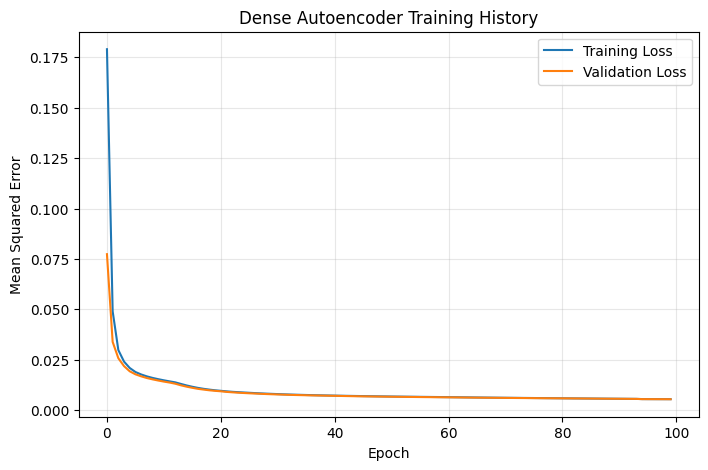

Saved: /content/drive/MyDrive/intentmap-nids/intentmap-nids/reports/autoencoder_training_history.png


In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Dense Autoencoder Training History")
plt.legend()
plt.grid(alpha=0.3)

TRAINING_PLOT = (
    REPORT_DIR / "autoencoder_training_history.png"
)

plt.savefig(
    TRAINING_PLOT,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", TRAINING_PLOT)

In [13]:
def reconstruction_errors(model, X):
    reconstructed = model.predict(
        X,
        batch_size=1024,
        verbose=0
    )

    errors = np.mean(
        np.square(X - reconstructed),
        axis=1
    )

    return errors


train_errors = reconstruction_errors(
    autoencoder,
    X_train
)

val_errors = reconstruction_errors(
    autoencoder,
    X_val
)

test_errors = reconstruction_errors(
    autoencoder,
    X_test
)

print("Train reconstruction error:")
print(
    "Mean:",
    train_errors.mean(),
    "Std:",
    train_errors.std()
)

print("\nValidation reconstruction error:")
print(
    "Mean:",
    val_errors.mean(),
    "Std:",
    val_errors.std()
)

print("\nTest reconstruction error:")
print(
    "Mean:",
    test_errors.mean(),
    "Std:",
    test_errors.std()
)

Train reconstruction error:
Mean: 0.005425932448338542 Std: 0.00892244696005098

Validation reconstruction error:
Mean: 0.005424621433109636 Std: 0.008891408738641832

Test reconstruction error:
Mean: 0.048848341575980156 Std: 0.06785531617610664


In [14]:
fp_budgets = {
    "0.5% budget": 0.005,
    "1% budget": 0.01,
    "3% budget": 0.03
}

thresholds = {}

for label, budget in fp_budgets.items():

    threshold = np.quantile(
        val_errors,
        1 - budget
    )

    thresholds[label] = threshold

    validation_predictions = (
        val_errors >= threshold
    ).astype(int)

    validation_fp_rate = (
        validation_predictions.mean()
    )

    print(
        f"{label}: "
        f"threshold={threshold:.8f}, "
        f"validation anomaly rate="
        f"{validation_fp_rate:.4%}"
    )

0.5% budget: threshold=0.04577401, validation anomaly rate=0.5065%
1% budget: threshold=0.03646767, validation anomaly rate=1.0033%
3% budget: threshold=0.02375446, validation anomaly rate=3.0002%


In [15]:
def evaluate_threshold(
    y_true,
    scores,
    threshold
):

    predictions = (
        scores >= threshold
    ).astype(int)

    precision = precision_score(
        y_true,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        predictions,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    actual_fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0
    )

    false_alerts_per_1000 = (
        actual_fpr * 1000
    )

    return {
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Actual FPR": actual_fpr,
        "False alerts per 1000": false_alerts_per_1000,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

In [16]:
evaluation_rows = []

for label, threshold in thresholds.items():

    metrics = evaluate_threshold(
        y_test,
        test_errors,
        threshold
    )

    metrics["Budget"] = label

    evaluation_rows.append(
        metrics
    )

ae_budget_results = pd.DataFrame(
    evaluation_rows
)

ae_budget_results = ae_budget_results[
    [
        "Budget",
        "Threshold",
        "Precision",
        "Recall",
        "F1",
        "Actual FPR",
        "False alerts per 1000",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
]

display(ae_budget_results)

,Budget,Threshold,Precision,Recall,F1,Actual FPR,False alerts per 1000,TN,FP,FN,TP
0,0.5% budget,0.045774,0.947172,0.588525,0.725969,0.040216,40.216216,35512,1488,18653,26679
1,1% budget,0.036468,0.936372,0.632710,0.755157,0.052676,52.675676,35051,1949,16650,28682
2,3% budget,0.023754,0.912602,0.673983,0.775349,0.079081,79.081081,34074,2926,14779,30553


In [17]:
ae_roc_auc = roc_auc_score(
    y_test,
    test_errors
)

ae_pr_auc = average_precision_score(
    y_test,
    test_errors
)

print(
    f"Autoencoder ROC-AUC: "
    f"{ae_roc_auc:.4f}"
)

print(
    f"Autoencoder PR-AUC: "
    f"{ae_pr_auc:.4f}"
)

Autoencoder ROC-AUC: 0.8785
Autoencoder PR-AUC: 0.9011


In [18]:
AE_BUDGET_FILE = (
    REPORT_DIR / "autoencoder_budget_results.csv"
)

ae_budget_results.to_csv(
    AE_BUDGET_FILE,
    index=False
)

print(
    "Saved:",
    AE_BUDGET_FILE
)

Saved: /content/drive/MyDrive/intentmap-nids/intentmap-nids/reports/autoencoder_budget_results.csv


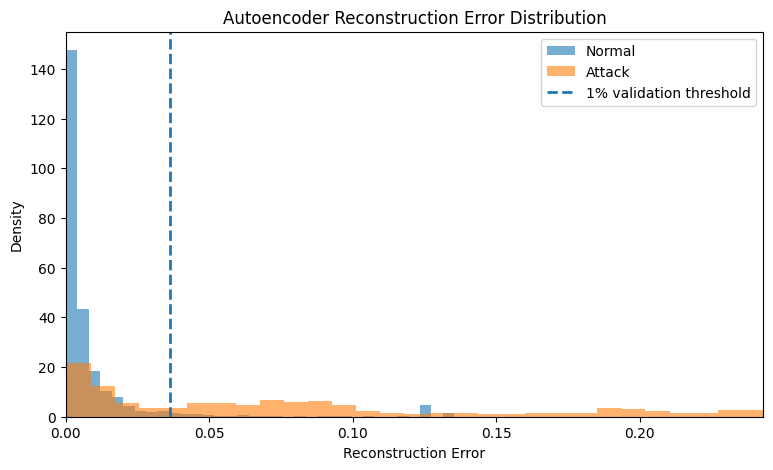

Saved: /content/drive/MyDrive/intentmap-nids/intentmap-nids/reports/autoencoder_scores.png


In [19]:
normal_errors = test_errors[
    y_test == 0
]

attack_errors = test_errors[
    y_test == 1
]

plt.figure(figsize=(9, 5))

plt.hist(
    normal_errors,
    bins=100,
    alpha=0.6,
    density=True,
    label="Normal"
)

plt.hist(
    attack_errors,
    bins=100,
    alpha=0.6,
    density=True,
    label="Attack"
)

plt.axvline(
    thresholds["1% budget"],
    linestyle="--",
    linewidth=2,
    label="1% validation threshold"
)

plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
plt.title(
    "Autoencoder Reconstruction Error Distribution"
)

plt.legend()

# Reconstruction errors can have long tails.
# This can make the graph easier to read.
plt.xlim(
    left=0,
    right=np.percentile(
        test_errors,
        99
    )
)

AE_SCORE_PLOT = (
    REPORT_DIR / "autoencoder_scores.png"
)

plt.savefig(
    AE_SCORE_PLOT,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    AE_SCORE_PLOT
)

In [20]:
threshold_005 = thresholds[
    "0.5% budget"
]

threshold_01 = thresholds[
    "1% budget"
]

threshold_03 = thresholds[
    "3% budget"
]


ae_pred_005 = (
    test_errors >= threshold_005
).astype(int)

ae_pred_01 = (
    test_errors >= threshold_01
).astype(int)

ae_pred_03 = (
    test_errors >= threshold_03
).astype(int)


ae_dashboard_results = pd.DataFrame({
    "record_id":
        range(
            1,
            len(test_errors) + 1
        ),

    "actual_label":
        y_test,

    "actual_class":
        [
            "Attack"
            if y == 1
            else "Normal"
            for y in y_test
        ],

    "ae_score":
        test_errors,

    "ae_prediction_0.5pct":
        ae_pred_005,

    "ae_prediction_1pct":
        ae_pred_01,

    "ae_prediction_3pct":
        ae_pred_03,

    "ae_status_0.5pct":
        [
            "Anomaly"
            if p == 1
            else "Normal"
            for p in ae_pred_005
        ],

    "ae_status_1pct":
        [
            "Anomaly"
            if p == 1
            else "Normal"
            for p in ae_pred_01
        ],

    "ae_status_3pct":
        [
            "Anomaly"
            if p == 1
            else "Normal"
            for p in ae_pred_03
        ]
})


# 1% = default dashboard setting
ae_dashboard_results[
    "default_threshold"
] = threshold_01

ae_dashboard_results[
    "default_prediction"
] = ae_pred_01

ae_dashboard_results[
    "default_status"
] = [
    "Anomaly"
    if p == 1
    else "Normal"
    for p in ae_pred_01
]

ae_dashboard_results[
    "correct_prediction"
] = (
    ae_dashboard_results[
        "default_prediction"
    ]
    ==
    ae_dashboard_results[
        "actual_label"
    ]
)

AE_DASHBOARD_FILE = (
    REPORT_DIR /
    "autoencoder_dashboard_results.csv"
)

ae_dashboard_results.to_csv(
    AE_DASHBOARD_FILE,
    index=False
)

print(
    "Dashboard results saved:"
)

print(
    AE_DASHBOARD_FILE
)

print(
    "Shape:",
    ae_dashboard_results.shape
)

display(
    ae_dashboard_results.head(10)
)

Dashboard results saved:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/reports/autoencoder_dashboard_results.csv
Shape: (82332, 14)


,record_id,actual_label,actual_class,ae_score,ae_prediction_0.5pct,ae_prediction_1pct,ae_prediction_3pct,ae_status_0.5pct,ae_status_1pct,ae_status_3pct,default_threshold,default_prediction,default_status,correct_prediction
0,1,0,Normal,0.001089,0,0,0,Normal,Normal,Normal,0.036468,0,Normal,True
1,2,0,Normal,0.002705,0,0,0,Normal,Normal,Normal,0.036468,0,Normal,True
2,3,0,Normal,0.001193,0,0,0,Normal,Normal,Normal,0.036468,0,Normal,True
3,4,0,Normal,0.000792,0,0,0,Normal,Normal,Normal,0.036468,0,Normal,True
4,5,0,Normal,0.002585,0,0,0,Normal,Normal,Normal,0.036468,0,Normal,True
5,6,0,Normal,0.001073,0,0,0,Normal,Normal,Normal,0.036468,0,Normal,True
6,7,0,Normal,0.002580,0,0,0,Normal,Normal,Normal,0.036468,0,Normal,True
7,8,0,Normal,0.003019,0,0,0,Normal,Normal,Normal,0.036468,0,Normal,True
8,9,0,Normal,0.131769,1,1,1,Anomaly,Anomaly,Anomaly,0.036468,1,Anomaly,False
9,10,0,Normal,0.131769,1,1,1,Anomaly,Anomaly,Anomaly,0.036468,1,Anomaly,False


In [21]:
X_test_reconstructed = autoencoder.predict(
    X_test,
    batch_size=1024,
    verbose=0
)

feature_reconstruction_errors = np.square(
    X_test - X_test_reconstructed
)

print(
    "Feature error matrix:",
    feature_reconstruction_errors.shape
)

Feature error matrix: (82332, 41)


In [22]:
print("Config files:")

for file in CONFIG_DIR.iterdir():
    print(file.name)

Config files:
feature_dictionary.csv
feature_order.json


In [23]:
FEATURE_ORDER_FILE = (
    CONFIG_DIR / "feature_order.json"
)

if FEATURE_ORDER_FILE.exists():

    with open(
        FEATURE_ORDER_FILE,
        "r"
    ) as f:

        feature_info = json.load(f)

    if isinstance(feature_info, list):
        feature_names = feature_info

    elif "features" in feature_info:
        feature_names = feature_info[
            "features"
        ]

    else:
        feature_names = [
            f"feature_{i}"
            for i in range(
                X_test.shape[1]
            )
        ]

else:

    feature_names = [
        f"feature_{i}"
        for i in range(
            X_test.shape[1]
        )
    ]


print(
    "Number of feature names:",
    len(feature_names)
)

print(
    feature_names[:10]
)

Number of feature names: 41
['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9']


In [24]:
top_k = 3

top_indices = np.argsort(
    feature_reconstruction_errors,
    axis=1
)[:, -top_k:][:, ::-1]


top_feature_1 = []
top_feature_2 = []
top_feature_3 = []

top_error_1 = []
top_error_2 = []
top_error_3 = []


for row_index in range(
    len(top_indices)
):

    indices = top_indices[
        row_index
    ]

    errors = (
        feature_reconstruction_errors[
            row_index,
            indices
        ]
    )

    top_feature_1.append(
        feature_names[
            indices[0]
        ]
    )

    top_feature_2.append(
        feature_names[
            indices[1]
        ]
    )

    top_feature_3.append(
        feature_names[
            indices[2]
        ]
    )

    top_error_1.append(
        errors[0]
    )

    top_error_2.append(
        errors[1]
    )

    top_error_3.append(
        errors[2]
    )


ae_dashboard_results[
    "top_feature_1"
] = top_feature_1

ae_dashboard_results[
    "top_feature_1_error"
] = top_error_1

ae_dashboard_results[
    "top_feature_2"
] = top_feature_2

ae_dashboard_results[
    "top_feature_2_error"
] = top_error_2

ae_dashboard_results[
    "top_feature_3"
] = top_feature_3

ae_dashboard_results[
    "top_feature_3_error"
] = top_error_3


# Re-save dashboard CSV
ae_dashboard_results.to_csv(
    AE_DASHBOARD_FILE,
    index=False
)

display(
    ae_dashboard_results[
        [
            "record_id",
            "ae_score",
            "default_status",
            "top_feature_1",
            "top_feature_2",
            "top_feature_3"
        ]
    ].head(10)
)

,record_id,ae_score,default_status,top_feature_1,top_feature_2,top_feature_3
0,1,0.001089,Normal,feature_25,feature_0,feature_5
1,2,0.002705,Normal,feature_31,feature_32,feature_11
2,3,0.001193,Normal,feature_31,feature_25,feature_32
3,4,0.000792,Normal,feature_10,feature_31,feature_25
4,5,0.002585,Normal,feature_31,feature_25,feature_3
5,6,0.001073,Normal,feature_10,feature_14,feature_4
6,7,0.002580,Normal,feature_4,feature_31,feature_3
7,8,0.003019,Normal,feature_11,feature_31,feature_5
8,9,0.131769,Anomaly,feature_6,feature_17,feature_18
9,10,0.131769,Anomaly,feature_6,feature_17,feature_18


In [25]:
AE_MODEL_FILE = (
    MODEL_DIR /
    "autoencoder_candidate1.keras"
)

autoencoder.save(
    AE_MODEL_FILE
)

print(
    "Saved Autoencoder:"
)

print(
    AE_MODEL_FILE
)

Saved Autoencoder:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/models/autoencoder_candidate1.keras


In [26]:
AE_CONFIG_FILE = (
    CONFIG_DIR /
    "autoencoder_candidate1.json"
)

autoencoder_information = {

    "model":
        "Dense Autoencoder",

    "purpose":
        "Unsupervised network anomaly detection",

    "training_data":
        "train_normal.npz",

    "validation_data":
        "val_normal.npz",

    "test_data":
        "test_full.npz",

    "input_features":
        int(input_dim),

    "architecture": [
        int(input_dim),
        32,
        16,
        8,
        16,
        32,
        int(input_dim)
    ],

    "bottleneck":
        8,

    "hidden_activation":
        "relu",

    "output_activation":
        "linear",

    "loss":
        "mean_squared_error",

    "optimizer":
        "Adam",

    "initial_learning_rate":
        0.001,

    "batch_size":
        256,

    "maximum_epochs":
        100,

    "random_seed":
        SEED,

    "roc_auc":
        float(ae_roc_auc),

    "pr_auc":
        float(ae_pr_auc),

    "thresholds": {
        label: float(value)
        for label, value
        in thresholds.items()
    }
}


with open(
    AE_CONFIG_FILE,
    "w"
) as f:

    json.dump(
        autoencoder_information,
        f,
        indent=4
    )


print(
    "Saved configuration:"
)

print(
    AE_CONFIG_FILE
)

Saved configuration:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/config/autoencoder_candidate1.json


In [27]:
files_to_check = [
    AE_MODEL_FILE,
    AE_CONFIG_FILE,
    AE_BUDGET_FILE,
    AE_DASHBOARD_FILE,
    AE_SCORE_PLOT,
    TRAINING_PLOT
]

for file in files_to_check:

    print(
        file.name,
        "->",
        file.exists()
    )

autoencoder_candidate1.keras -> True
autoencoder_candidate1.json -> True
autoencoder_budget_results.csv -> True
autoencoder_dashboard_results.csv -> True
autoencoder_scores.png -> True
autoencoder_training_history.png -> True


In [34]:
# ============================================================
# CREATE AUTOENCODER ZIP + AUTOMATICALLY DOWNLOAD
# ============================================================

import zipfile
from google.colab import files

# Create ZIP in Colab
AE_ZIP_FILE = "/content/Autoencoder_Results.zip"

files_to_zip = [
    AE_MODEL_FILE,
    AE_CONFIG_FILE,
    AE_BUDGET_FILE,
    AE_DASHBOARD_FILE,
    AE_SCORE_PLOT,
    TRAINING_PLOT
]

with zipfile.ZipFile(
    AE_ZIP_FILE,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    for file_path in files_to_zip:

        if file_path.exists():

            zipf.write(
                file_path,
                arcname=file_path.name
            )

            print("Added:", file_path.name)

        else:
            print("Missing:", file_path)


print("\nAutoencoder package created successfully:")
print(AE_ZIP_FILE)

# Automatically download to your computer
files.download(AE_ZIP_FILE)

Added: autoencoder_candidate1.keras
Added: autoencoder_candidate1.json
Added: autoencoder_budget_results.csv
Added: autoencoder_dashboard_results.csv
Added: autoencoder_scores.png
Added: autoencoder_training_history.png

Autoencoder package created successfully:
/content/Autoencoder_Results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>